In [3]:
import pandas as pd
import matplotlib.pyplot as plt

path = "../datasets/ROUND1/prices_round_1_day_-1.csv"

# Load CSV
df = pd.read_csv(path, sep=';')



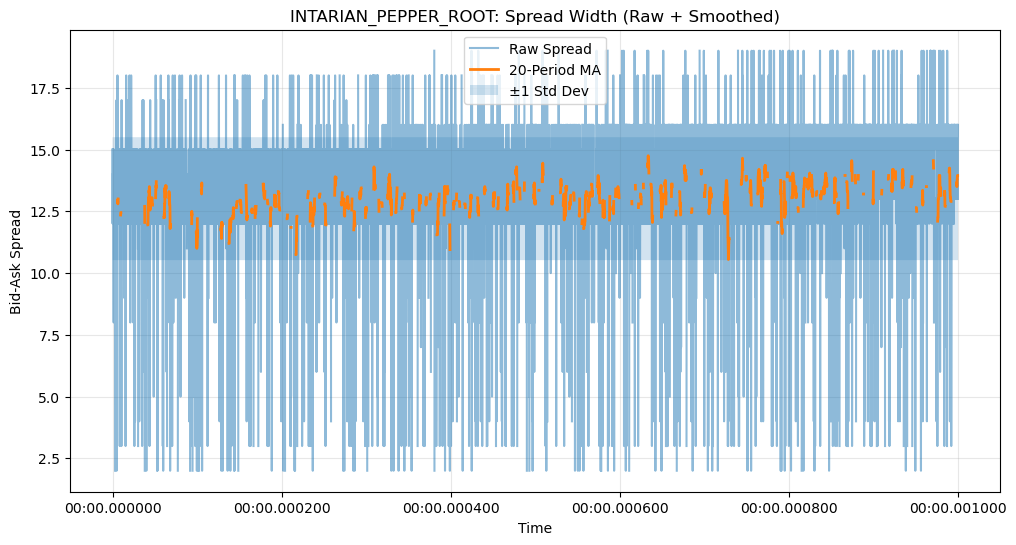

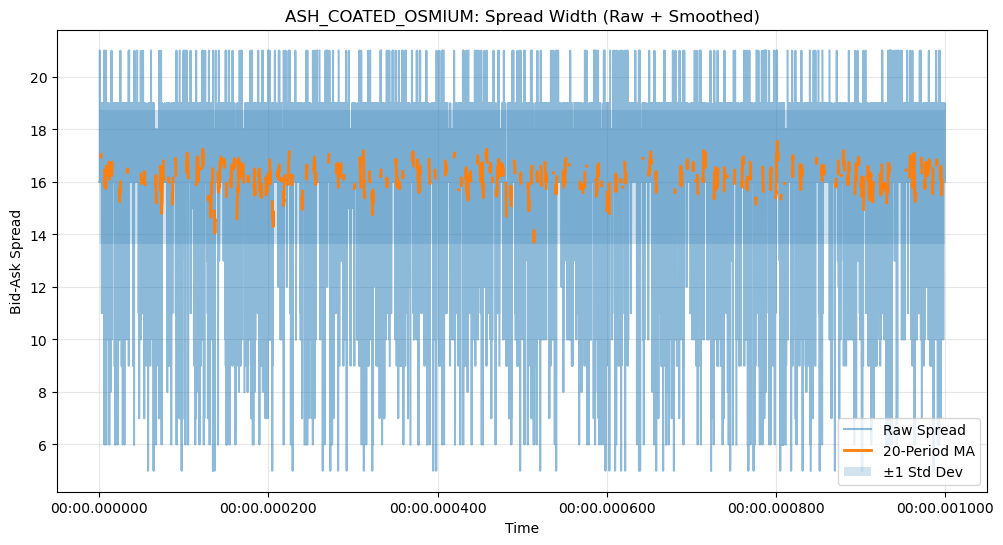

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['spread'] = df['ask_price_1'] - df['bid_price_1']

for product in df['product'].unique():
    product_data = df[df['product'] == product].sort_values('timestamp')
    product_data['spread_ma'] = product_data['spread'].rolling(window=20).mean()
    
    plt.figure(figsize=(12, 6))
    plt.plot(product_data['timestamp'], product_data['spread'], alpha=0.5, label='Raw Spread')
    plt.plot(product_data['timestamp'], product_data['spread_ma'], linewidth=2, label='20-Period MA')
    plt.fill_between(product_data['timestamp'], 
                      product_data['spread'].mean() - product_data['spread'].std(),
                      product_data['spread'].mean() + product_data['spread'].std(),
                      alpha=0.2, label='±1 Std Dev')
    plt.xlabel('Time')
    plt.ylabel('Bid-Ask Spread')
    plt.title(f'{product}: Spread Width (Raw + Smoothed)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

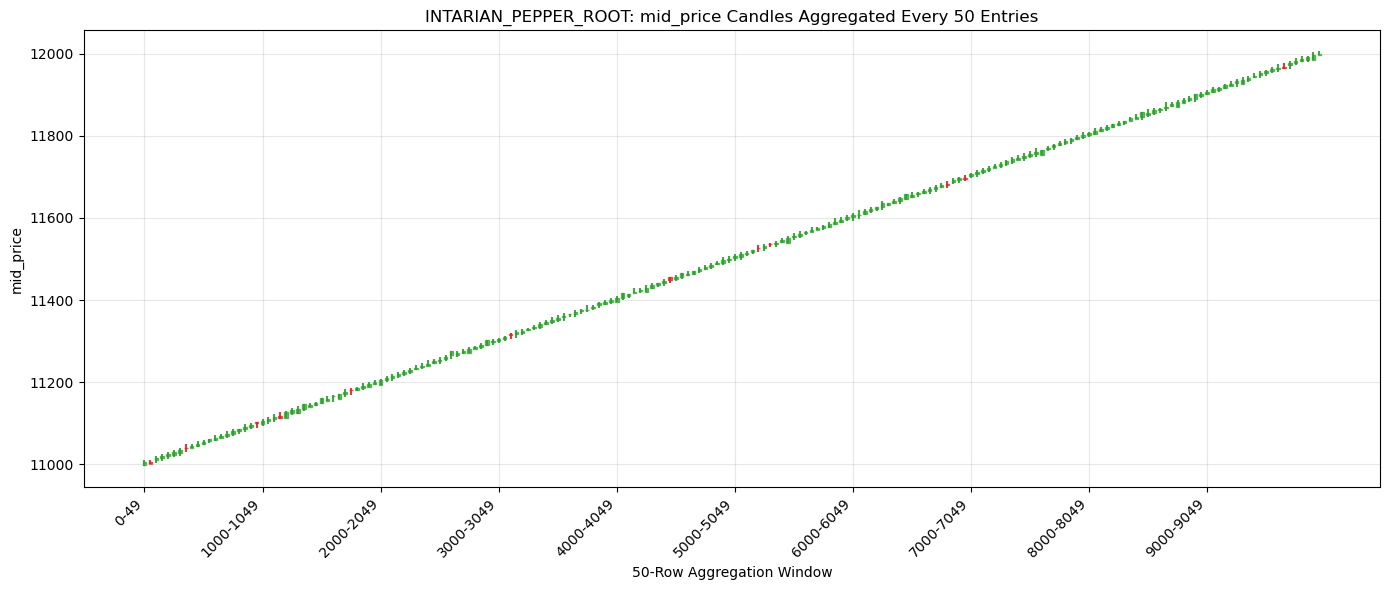

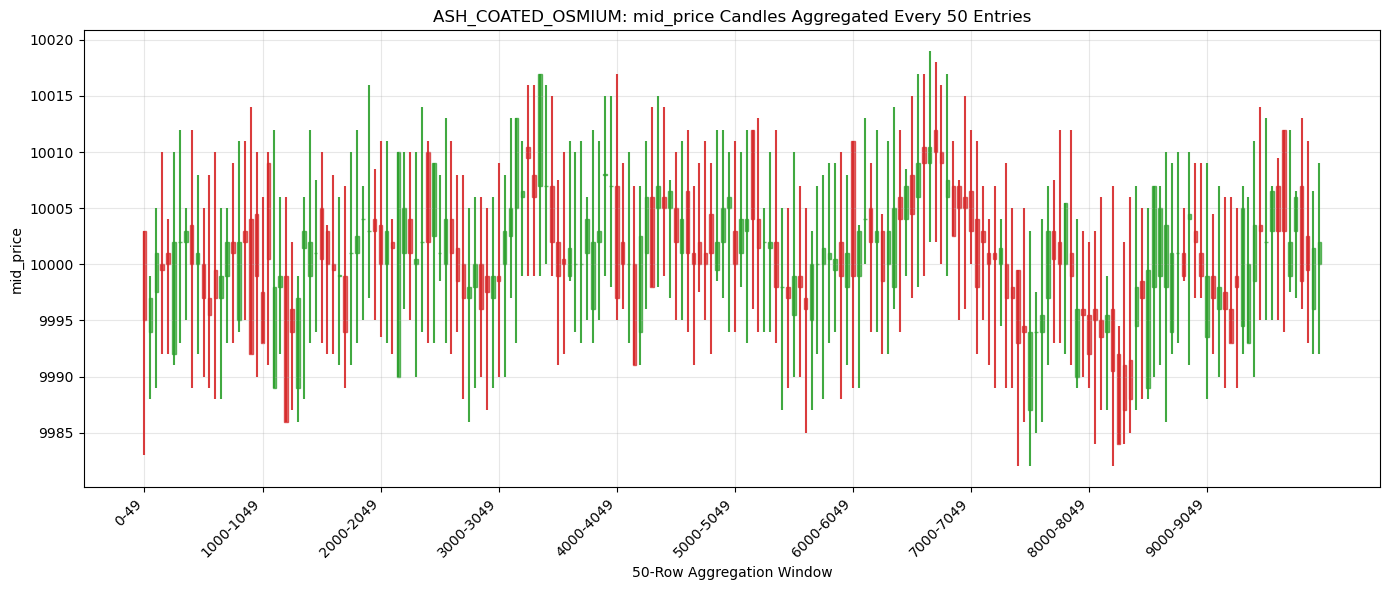

In [9]:
from matplotlib.patches import Rectangle

price_column = 'mid_price'
group_size = 50

for product in df['product'].unique():
    product_data = df[df['product'] == product].sort_values('timestamp').reset_index(drop=True)
    product_data = product_data[product_data[price_column].notna() & (product_data[price_column] > 0)].reset_index(drop=True)

    if product_data.empty:
        continue

    grouped = product_data.groupby(product_data.index // group_size)

    candles = grouped[price_column].agg(['first', 'max', 'min', 'last']).reset_index(drop=True)
    if candles.empty:
        continue

    fig, ax = plt.subplots(figsize=(14, 6))

    for x, candle in candles.iterrows():
        open_price = candle['first']
        high_price = candle['max']
        low_price = candle['min']
        close_price = candle['last']
        color = '#2ca02c' if close_price >= open_price else '#d62728'

        ax.vlines(x, low_price, high_price, color=color, linewidth=1.5, alpha=0.9)

        body_bottom = min(open_price, close_price)
        body_height = max(abs(close_price - open_price), 0.01)
        ax.add_patch(Rectangle((x - 0.3, body_bottom), 0.6, body_height, facecolor=color, edgecolor=color, alpha=0.7))

    tick_step = max(len(candles) // 10, 1)
    tick_positions = list(range(0, len(candles), tick_step))
    tick_labels = [f"{i * group_size}-{min((i + 1) * group_size - 1, len(product_data) - 1)}" for i in tick_positions]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    ax.set_xlabel('50-Row Aggregation Window')
    ax.set_ylabel(price_column)
    ax.set_title(f'{product}: {price_column} Candles Aggregated Every {group_size} Entries')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()